# Лабораторная работа 2

## 1. Процесс анализа: выполненные этапы анализа и итерации
### 1.0 Импорт необходимых библиотек

In [2]:
from pathlib import Path
from collections import Counter
import csv

import matplotlib.pyplot as plt
import numpy as np


### 1.1. Подготовка окружения и описание источника данных


In [3]:
BASE_DIR = Path.cwd()
DATASET_ROOT = BASE_DIR / 'dataset' / 'XOR_Arbiter_PUFs'

DATASETS = {
    '6xor_64bit': {
        'train': DATASET_ROOT / '6xor_64bit' / 'train_6xor_64dim.csv',
        'test': DATASET_ROOT / '6xor_64bit' / 'test_6xor_64dim.csv',
        'n_features': 64
    },
    '5xor_128bit': {
        'train': DATASET_ROOT / '5xor_128bit' / 'train_5xor_128dim.csv',
        'test': DATASET_ROOT / '5xor_128bit' / 'test_5xor_128dim.csv',
        'n_features': 128
    }
}

DATASET_KEY = '6xor_64bit'
dataset_cfg = DATASETS[DATASET_KEY]
dataset_cfg


{'train': PosixPath('/home/jupyter/project/dataset/XOR_Arbiter_PUFs/6xor_64bit/train_6xor_64dim.csv'),
 'test': PosixPath('/home/jupyter/project/dataset/XOR_Arbiter_PUFs/6xor_64bit/test_6xor_64dim.csv'),
 'n_features': 64}

## 3. Настройки функций


In [4]:
def count_rows(file_path: Path) -> int:
    with file_path.open('r', encoding='utf-8', newline='') as fh:
        return sum(1 for _ in fh)


def load_csv_int8(file_path: Path, n_features: int) -> np.ndarray:
    rows = count_rows(file_path)
    cols = n_features + 1
    data = np.empty((rows, cols), dtype=np.int8)

    with file_path.open('r', encoding='utf-8', newline='') as fh:
        reader = csv.reader(fh)
        for i, row in enumerate(reader):
            data[i] = np.fromiter((int(value) for value in row), dtype=np.int8, count=cols)

    return data


def split_features_target(data: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    return data[:, :-1], data[:, -1]


### 3.1. Функции кодирования, проверки и стандартизации данных


In [5]:
def encode_pm1_to_binary(arr: np.ndarray) -> np.ndarray:
    return ((arr + 1) // 2).astype(np.int8)


def ensure_pm1_encoding(arr: np.ndarray) -> np.ndarray:
    unique_values = set(np.unique(arr).tolist())
    if unique_values.issubset({-1, 1}):
        return arr.astype(np.int8)
    if unique_values.issubset({0, 1}):
        return np.where(arr == 0, -1, 1).astype(np.int8)
    raise ValueError(f'Ожидались значения из {-1, 1} или {0, 1}, получено: {unique_values}')


def build_phi_features_from_pm1(challenges: np.ndarray) -> np.ndarray:
    challenges_pm1 = ensure_pm1_encoding(challenges)
    n_rows, n_features = challenges_pm1.shape
    phi = np.empty((n_rows, n_features), dtype=np.int8)
    running_product = np.ones(n_rows, dtype=np.int8)

    for idx in range(n_features - 1, -1, -1):
        running_product = (running_product * challenges_pm1[:, idx]).astype(np.int8)
        phi[:, idx] = running_product

    return phi


def build_feature_views(X_train_raw: np.ndarray, X_test_raw: np.ndarray) -> dict:
    X_train_pm1 = ensure_pm1_encoding(X_train_raw)
    X_test_pm1 = ensure_pm1_encoding(X_test_raw)

    return {
        'raw': {
            'X_train': encode_pm1_to_binary(X_train_pm1),
            'X_test': encode_pm1_to_binary(X_test_pm1),
            'description': 'Исходные challenge-биты в кодировке 0/1'
        },
        'phi': {
            'X_train': build_phi_features_from_pm1(X_train_pm1),
            'X_test': build_phi_features_from_pm1(X_test_pm1),
            'description': 'Phi-features для линейного моделирования Arbiter PUF'
        }
    }


def summarize_target(y: np.ndarray) -> dict:
    counts = Counter(y.tolist())
    total = len(y)
    return {
        'counts': dict(counts),
        'share': {label: round(count / total, 4) for label, count in counts.items()}
    }


def standardize_binary_features(X_train_bin: np.ndarray, X_test_bin: np.ndarray):
    mean = X_train_bin.mean(axis=0, dtype=np.float32)
    std = X_train_bin.std(axis=0, dtype=np.float32)
    std_safe = np.where(std == 0, 1.0, std)
    X_train_std = ((X_train_bin - mean) / std_safe).astype(np.float32)
    X_test_std = ((X_test_bin - mean) / std_safe).astype(np.float32)
    return X_train_std, X_test_std, mean, std


### 1.2. Загрузка датасета и разделение признаков и целевой переменной


In [6]:
train_raw = load_csv_int8(dataset_cfg['train'], dataset_cfg['n_features'])
test_raw = load_csv_int8(dataset_cfg['test'], dataset_cfg['n_features'])

X_train_raw, y_train_raw = split_features_target(train_raw)
X_test_raw, y_test_raw = split_features_target(test_raw)


In [7]:
print('Выбранный набор:', DATASET_KEY)
print('Train shape:', train_raw.shape)
print('Test shape:', test_raw.shape)
print('Число признаков:', X_train_raw.shape[1])


Выбранный набор: 6xor_64bit
Train shape: (2000000, 65)
Test shape: (400000, 65)
Число признаков: 64


In [8]:
allowed_values = {-1, 1}

assert set(np.unique(X_train_raw).tolist()).issubset(allowed_values)
assert set(np.unique(X_test_raw).tolist()).issubset(allowed_values)
assert set(np.unique(y_train_raw).tolist()).issubset(allowed_values)
assert set(np.unique(y_test_raw).tolist()).issubset(allowed_values)

train_balance = summarize_target(y_train_raw)
test_balance = summarize_target(y_test_raw)

print('Баланс классов train:', train_balance)
print('Баланс классов test:', test_balance)


Баланс классов train: {'counts': {1: 1000020, -1: 999980}, 'share': {1: 0.5, -1: 0.5}}
Баланс классов test: {'counts': {-1: 200572, 1: 199428}, 'share': {-1: 0.5014, 1: 0.4986}}


### 3.2. Функции визуализации


In [9]:
def plot_class_balance(train_summary: dict, test_summary: dict) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

    for ax, summary, title in zip(
        axes,
        [train_summary, test_summary],
        ['Train', 'Test']
    ):
        labels = [str(label) for label in sorted(summary['counts'])]
        counts = [summary['counts'][int(label)] for label in labels]
        shares = [summary['share'][int(label)] for label in labels]

        bars = ax.bar(labels, counts, color=['#4c78a8', '#f58518'])
        ax.set_title(f'Баланс классов: {title}')
        ax.set_xlabel('Класс')
        ax.set_ylabel('Количество объектов')

        for bar, count, share in zip(bars, counts, shares):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f'{count:}\n({share:.2%})',
                ha='center',
                va='bottom'
            )

    plt.show()


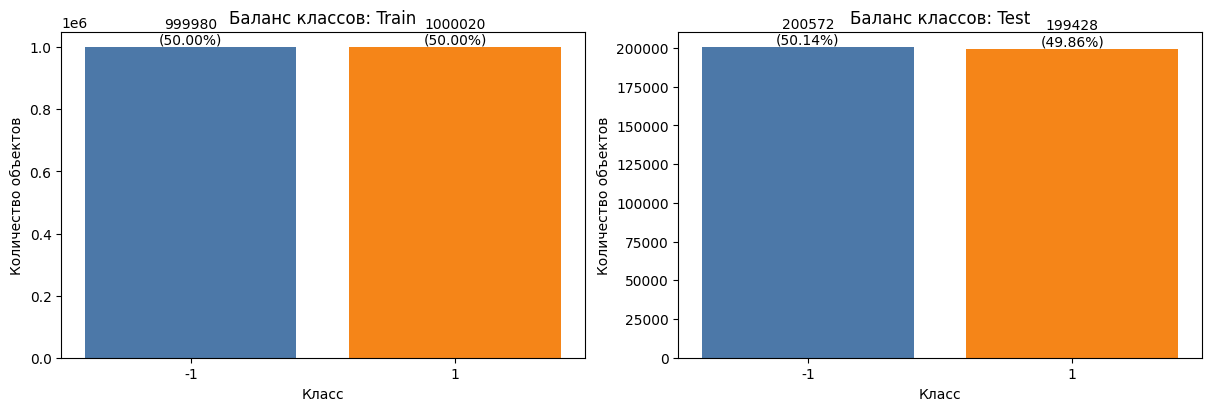

In [10]:
plot_class_balance(train_balance, test_balance)


## 2. Настройки и преобразования данных

В этом пункте выполняем преобразование исходных значений и подготавливаем данные для последующего обучения модели

In [11]:
FEATURE_MODE = 'phi'
AVAILABLE_FEATURE_MODES = ['raw', 'phi']

assert FEATURE_MODE in AVAILABLE_FEATURE_MODES
FEATURE_MODE


'phi'

In [12]:
feature_views = build_feature_views(X_train_raw, X_test_raw)

X_train_views = {mode: payload['X_train'] for mode, payload in feature_views.items()}
X_test_views = {mode: payload['X_test'] for mode, payload in feature_views.items()}

X_train = X_train_views[FEATURE_MODE]
X_test = X_test_views[FEATURE_MODE]
y_train = encode_pm1_to_binary(y_train_raw)
y_test = encode_pm1_to_binary(y_test_raw)

print('Выбранное представление признаков:', FEATURE_MODE)
print('Описание:', feature_views[FEATURE_MODE]['description'])
print('Форма X_train:', X_train.shape)
print('Форма X_test:', X_test.shape)
print('После кодирования уникальные значения y_train:', np.unique(y_train))
print('После кодирования уникальные значения y_test:', np.unique(y_test))


Выбранное представление признаков: phi
Описание: Phi-features для линейного моделирования Arbiter PUF
Форма X_train: (2000000, 64)
Форма X_test: (400000, 64)
После кодирования уникальные значения y_train: [0 1]
После кодирования уникальные значения y_test: [0 1]


In [13]:
standardized_views = {}

for mode in AVAILABLE_FEATURE_MODES:
    X_train_std_mode, X_test_std_mode, feature_mean_mode, feature_std_mode = standardize_binary_features(
        X_train_views[mode],
        X_test_views[mode]
    )

    standardized_views[mode] = {
        'X_train_std': X_train_std_mode,
        'X_test_std': X_test_std_mode,
        'feature_mean': feature_mean_mode,
        'feature_std': feature_std_mode
    }

X_train_std = standardized_views[FEATURE_MODE]['X_train_std']
X_test_std = standardized_views[FEATURE_MODE]['X_test_std']
feature_mean = standardized_views[FEATURE_MODE]['feature_mean']
feature_std = standardized_views[FEATURE_MODE]['feature_std']

print('Стандартизованные данные готовы для режима:', FEATURE_MODE)
print('Размеры:', X_train_std.shape, X_test_std.shape)


Стандартизованные данные готовы для режима: phi
Размеры: (2000000, 64) (400000, 64)


In [14]:
prepared_data = {
    'dataset_key': DATASET_KEY,
    'feature_mode': FEATURE_MODE,
    'feature_views': feature_views,
    'X_train_views': X_train_views,
    'X_test_views': X_test_views,
    'standardized_views': standardized_views,
    'X_train': X_train,
    'X_test': X_test,
    'y_train': y_train,
    'y_test': y_test,
    'X_train_std': X_train_std,
    'X_test_std': X_test_std,
    'feature_mean': feature_mean,
    'feature_std': feature_std
}

print('Ключевые массивы для следующего этапа:', FEATURE_MODE, '-> X_train_std, y_train, X_test_std, y_test')


Ключевые массивы для следующего этапа: phi -> X_train_std, y_train, X_test_std, y_test


## 4. Настройки алгоритма


### Основные настройки модели

- `solver='saga'` - поддерживает `L1`-регуляризацию и подходит для больших выборок
- `penalty='l1'` - для использования `L1` -регуляризации
- `max_iter=200` - достаточное количество итераций для сходимости на большом объеме данных
- `class_weight='None'` - классы у нас сбалансированны, потому `None`, а не `balanced`
- `random_state=42` - выбрано и зафиксированно число, чтобы результаты можно было повторять

### Почему выбран именно этот алгоритм

- **Интерпретируемость.** Коэффициенты логистической регрессии можно напрямую анализировать, а `L1`-регуляризация делает модель разреженной
- **Масштабируемость.** Алгоритм хорошо работает на больших наборах данных и подходит для поставленной задачи бинарной классификации
- **Применимость к PUF.** Логистическая регрессия является классическим базовым методом для моделирующих атак на PUF и позволяет оценить потенциальную уязвимость схемы


### Связь настроек алгоритма с подготовкой данных

Выбранные ранее преобразования подготавливают данные именно под этот алгоритм. Разделение признаков и целевой переменной необходимо для обучения классификатора. Для `raw`-представления значения `{-1, 1}` переводятся в `0/1`, чтобы признаки были записаны в удобной бинарной форме. Для более физически осмысленного линейного моделирования Arbiter PUF дополнительно строятся `phi-features`, поскольку именно в этом пространстве зависимость отклика от входного вызова ближе к линейной. После выбора представления признаков выполняется стандартизация, необходимая для устойчивой работы логистической регрессии с `L1`-регуляризацией.


### Ожидаемый результат

Ожидается, что признаки будут влиять на результат примерно одинаково. Если после обучения окажется, что часть коэффициентов значительно выделяется, это будет говорить о более простой внутренней структуре зависимости и, следовательно, о потенциальной уязвимости PUF к моделирующим атакам.


### Метрики, которые будут использоваться далее

- **Accuracy** - оценка доли правильных предсказаний
- **ROC-AUC** - оценка способности модели разделять классы
- **LogLoss** - анализ качества вероятностных предсказаний
- **PR-AUC** - только если на следующих этапах появится заметный дисбаланс классов
- **Анализ коэффициентов модели** - интерпритация вклада отдельных признаков

## 5. Построение моделей алгоритмом: время построения в зависимости от объема данных

В этом пункте запускаем логистическую регрессию и эксперименты на разном объёмы выборок и числе вычислителей

In [15]:
import time
from contextlib import nullcontext

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score, average_precision_score

try:
    from threadpoolctl import threadpool_limits
except ImportError:
    threadpool_limits = None


In [22]:
MODEL_CONFIG = {
    'solver': 'saga',
    'penalty': 'l1',
    'max_iter': 200,
    'class_weight': None,
    'random_state': 42,
    'tol': 1e-4,
    'fit_intercept': True
}

MODEL_CONFIG


{'solver': 'saga',
 'penalty': 'l1',
 'max_iter': 200,
 'class_weight': None,
 'random_state': 42,
 'tol': 0.0001,
 'fit_intercept': True}

In [23]:
def build_logistic_regression(config: dict) -> LogisticRegression:
    return LogisticRegression(**config)


def evaluate_classifier(model, X_eval: np.ndarray, y_eval: np.ndarray) -> dict:
    y_pred = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:, 1]

    metrics = {
        'accuracy': float(accuracy_score(y_eval, y_pred)),
        'roc_auc': float(roc_auc_score(y_eval, y_proba)),
        'log_loss': float(log_loss(y_eval, y_proba))
    }

    unique_classes = np.unique(y_eval)
    if unique_classes.size == 2:
        metrics['pr_auc'] = float(average_precision_score(y_eval, y_proba))

    return metrics


def fit_and_measure(model, X_fit: np.ndarray, y_fit: np.ndarray):
    start_time = time.perf_counter()
    model.fit(X_fit, y_fit)
    fit_time = time.perf_counter() - start_time
    return model, fit_time


def predict_and_measure(model, X_eval: np.ndarray):
    start_time = time.perf_counter()
    y_pred = model.predict(X_eval)
    predict_time = time.perf_counter() - start_time
    return y_pred, predict_time


def subset_by_size(X: np.ndarray, y: np.ndarray, n_rows: int):
    return X[:n_rows], y[:n_rows]


def fit_with_thread_limit(model, X_fit: np.ndarray, y_fit: np.ndarray, n_threads: int):
    context = nullcontext() if threadpool_limits is None else threadpool_limits(limits=n_threads)
    with context:
        return fit_and_measure(model, X_fit, y_fit)


def run_single_experiment(X_train_input: np.ndarray, X_test_input: np.ndarray, y_train_input: np.ndarray, y_test_input: np.ndarray, config: dict, n_threads: int = 1) -> dict:
    model = build_logistic_regression(config)
    model, fit_time = fit_with_thread_limit(model, X_train_input, y_train_input, n_threads)

    _, train_predict_time = predict_and_measure(model, X_train_input)
    _, test_predict_time = predict_and_measure(model, X_test_input)

    train_metrics_local = evaluate_classifier(model, X_train_input, y_train_input)
    test_metrics_local = evaluate_classifier(model, X_test_input, y_test_input)

    return {
        'model': model,
        'train_fit_time_sec': fit_time,
        'train_predict_time_sec': train_predict_time,
        'test_predict_time_sec': test_predict_time,
        'train_metrics': train_metrics_local,
        'test_metrics': test_metrics_local
    }

def format_text_table(rows: list[dict], columns: list[tuple[str, str]], title: str | None = None) -> str:
    string_rows = []
    for row in rows:
        string_rows.append({key: str(row.get(key, "")) for key, _ in columns})

    widths = {}
    for key, header in columns:
        widths[key] = max(len(header), *(len(r[key]) for r in string_rows)) if string_rows else len(header)

    def render_line(values):
        return " | ".join(str(value).ljust(widths[key]) for (key, _), value in zip(columns, values))

    header_line = render_line([header for _, header in columns])
    separator = "-+-".join("-" * widths[key] for key, _ in columns)
    body = [render_line([row[key] for key, _ in columns]) for row in string_rows]

    lines = [header_line, separator] + body
    if title:
        lines = [title, ""] + lines
    return "\n".join(lines)




In [24]:
selected_result = run_single_experiment(X_train_std, X_test_std, y_train, y_test, MODEL_CONFIG, n_threads=1)

model = selected_result['model']
train_fit_time = selected_result['train_fit_time_sec']
train_predict_time = selected_result['train_predict_time_sec']
test_predict_time = selected_result['test_predict_time_sec']
train_metrics = selected_result['train_metrics']
test_metrics = selected_result['test_metrics']

timing_summary = {
    'train_fit_time_sec': train_fit_time,
    'train_predict_time_sec': train_predict_time,
    'test_predict_time_sec': test_predict_time
}

timing_rows = [
    {'stage': 'Обучение на train', 'time_sec': f"{timing_summary['train_fit_time_sec']:.6f}"},
    {'stage': 'Предсказание на train', 'time_sec': f"{timing_summary['train_predict_time_sec']:.6f}"},
    {'stage': 'Предсказание на test', 'time_sec': f"{timing_summary['test_predict_time_sec']:.6f}"}
]

metric_names = ['accuracy', 'roc_auc', 'log_loss', 'pr_auc']
metric_rows = [
    {
        'metric': metric,
        'train': f"{train_metrics[metric]:.6f}" if metric in train_metrics else '-',
        'test': f"{test_metrics[metric]:.6f}" if metric in test_metrics else '-'
    }
    for metric in metric_names
]

print(f'Режим признаков: {FEATURE_MODE}')
print()
print(format_text_table(timing_rows, [('stage', 'Этап'), ('time_sec', 'Время, сек')], 'Сводка по времени базового запуска'))
print()
print(format_text_table(metric_rows, [('metric', 'Метрика'), ('train', 'Train'), ('test', 'Test')], 'Метрики модели на train и test'))


Режим признаков: phi

Сводка по времени базового запуска

Этап                  | Время, сек
----------------------+-----------
Обучение на train     | 155.838128
Предсказание на train | 0.093690  
Предсказание на test  | 0.025850  

Метрики модели на train и test

Метрика  | Train    | Test    
---------+----------+---------
accuracy | 0.502363 | 0.499283
roc_auc  | 0.503117 | 0.499559
log_loss | 0.693132 | 0.693164
pr_auc   | 0.502485 | 0.499204


### Пояснение

В базовом запуске измеряются:
1. Время обучения модели на `train`-датасете
2. Время предсказания на `train` и время предсказания на `test`

Это нужно для того, чтобы оценить вычислительные характеристики на обоих наборах данных

### 7.2. Интерпретируемость обученной модели

В этом пункте проанализируем коэффициенты обученной логистической регрессии. Поскольку для модели выбрана `L1`-регуляризация, коэффициенты можно использовать как оценку важности признаков: чем больше абсолютное значение веса, тем сильнее вклад признака в линейное решение модели.


In [25]:
selected_coefficients = model.coef_.ravel().astype(np.float64)
selected_abs_coefficients = np.abs(selected_coefficients)
sorted_feature_indices = np.argsort(selected_abs_coefficients)[::-1]

feature_importance_table = [
    {
        'feature_index': int(idx),
        'weight': float(selected_coefficients[idx]),
        'abs_weight': float(selected_abs_coefficients[idx])
    }
    for idx in sorted_feature_indices
]

TOP_FEATURES_TO_SHOW = 15
top_feature_importance = feature_importance_table[:TOP_FEATURES_TO_SHOW]

coef_summary = {
    'feature_mode': FEATURE_MODE,
    'n_features': int(selected_coefficients.size),
    'n_zero_weights': int(np.sum(np.isclose(selected_coefficients, 0.0))),
    'n_nonzero_weights': int(np.sum(~np.isclose(selected_coefficients, 0.0))),
    'share_zero_weights': float(np.mean(np.isclose(selected_coefficients, 0.0))),
    'mean_abs_coef': float(selected_abs_coefficients.mean()),
    'median_abs_coef': float(np.median(selected_abs_coefficients)),
    'std_abs_coef': float(selected_abs_coefficients.std()),
    'max_abs_coef': float(selected_abs_coefficients.max()),
    'min_abs_coef': float(selected_abs_coefficients.min())
}

coef_summary_rows = [
    {'metric': key, 'value': f'{value:.6f}' if isinstance(value, float) else value}
    for key, value in coef_summary.items()
]
top_feature_rows = [
    {
        'feature': f"feature_{row['feature_index']:03d}",
        'weight': f"{row['weight']:.6f}",
        'abs_weight': f"{row['abs_weight']:.6f}"
    }
    for row in top_feature_importance
]

print(format_text_table(coef_summary_rows, [('metric', 'Показатель'), ('value', 'Значение')], 'Сводка по коэффициентам модели'))
print()
print(format_text_table(top_feature_rows, [('feature', 'Признак'), ('weight', 'Вес'), ('abs_weight', '|Вес|')], 'Топ признаков по абсолютному значению коэффициента'))


Сводка по коэффициентам модели

Показатель         | Значение
-------------------+---------
feature_mode       | phi     
n_features         | 64      
n_zero_weights     | 0       
n_nonzero_weights  | 64      
share_zero_weights | 0.000000
mean_abs_coef      | 0.001090
median_abs_coef    | 0.000929
std_abs_coef       | 0.000875
max_abs_coef       | 0.003945
min_abs_coef       | 0.000021

Топ признаков по абсолютному значению коэффициента

Признак     | Вес       | |Вес|   
------------+-----------+---------
feature_005 | -0.003945 | 0.003945
feature_008 | 0.003404  | 0.003404
feature_051 | 0.003187  | 0.003187
feature_062 | 0.002610  | 0.002610
feature_054 | 0.002606  | 0.002606
feature_057 | -0.002589 | 0.002589
feature_045 | 0.002575  | 0.002575
feature_011 | -0.002095 | 0.002095
feature_058 | 0.001899  | 0.001899
feature_036 | -0.001830 | 0.001830
feature_002 | 0.001809  | 0.001809
feature_047 | -0.001780 | 0.001780
feature_049 | 0.001774  | 0.001774
feature_060 | 0.001742  | 0.00

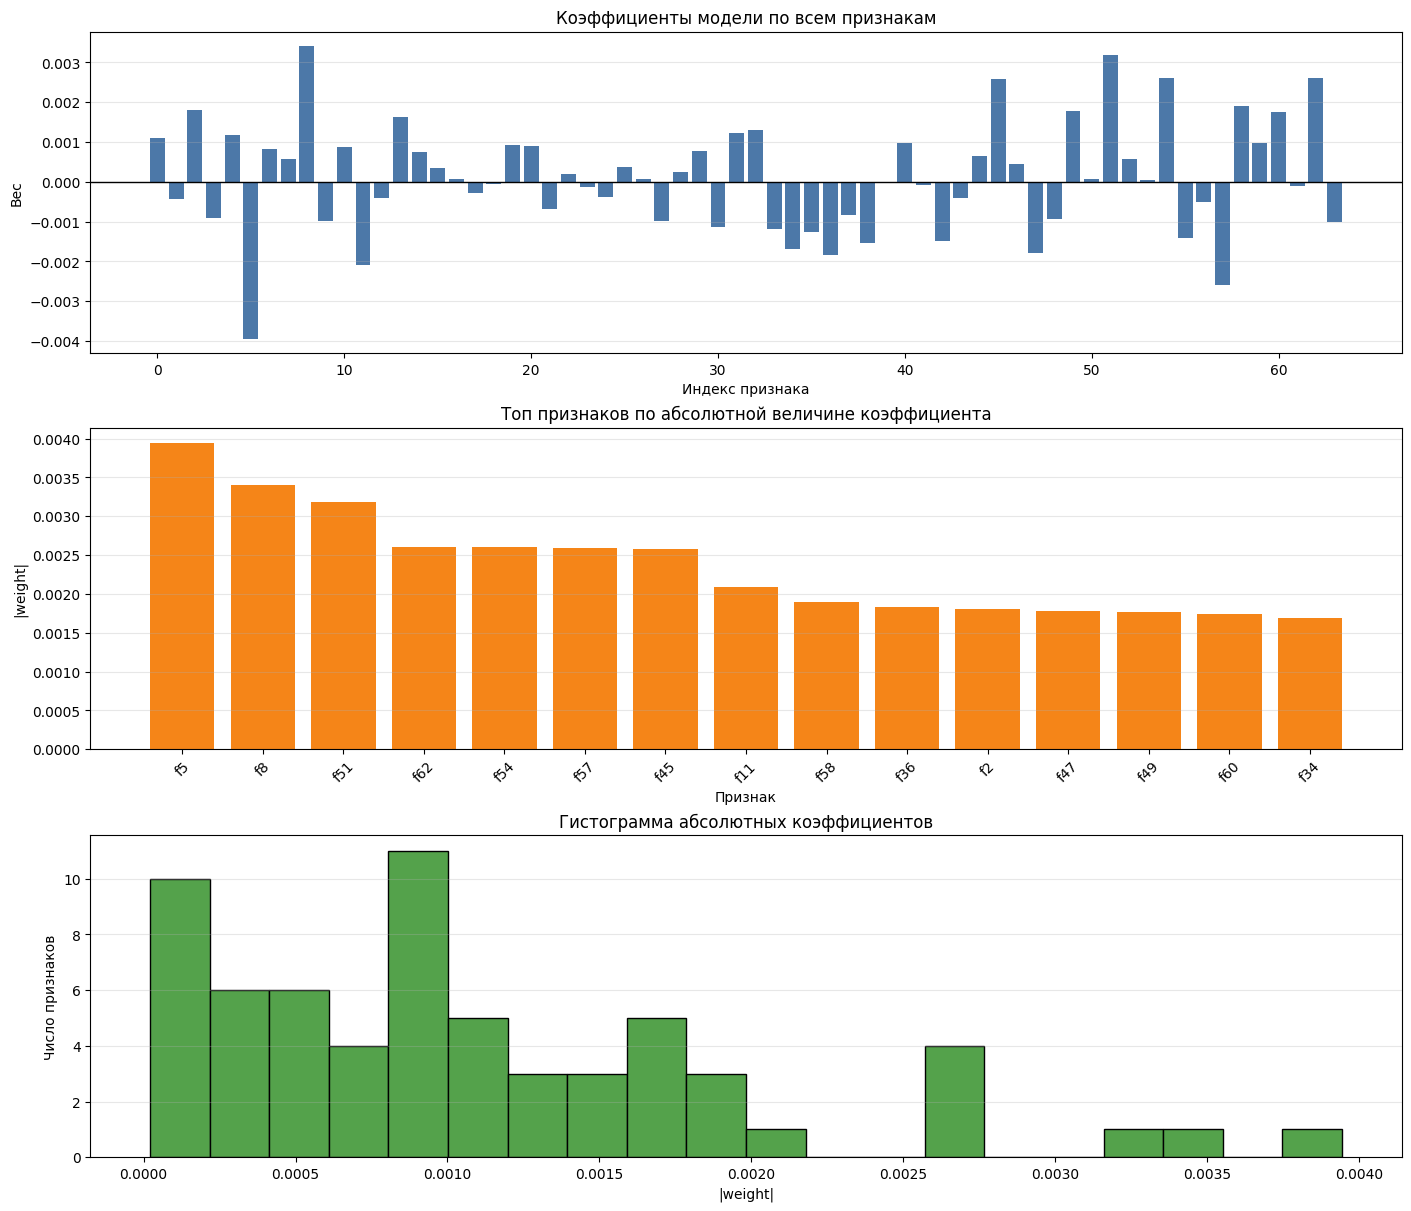

In [26]:
def plot_model_coefficients(coefficients: np.ndarray, top_feature_importance: list[dict]) -> None:
    feature_indices = np.arange(coefficients.size)
    abs_coefficients = np.abs(coefficients)

    fig, axes = plt.subplots(3, 1, figsize=(14, 12), constrained_layout=True)

    axes[0].bar(feature_indices, coefficients, color='#4c78a8')
    axes[0].axhline(0.0, color='black', linewidth=1)
    axes[0].set_title('Коэффициенты модели по всем признакам')
    axes[0].set_xlabel('Индекс признака')
    axes[0].set_ylabel('Вес')
    axes[0].grid(axis='y', alpha=0.3)

    top_labels = [f"f{row['feature_index']}" for row in top_feature_importance]
    top_values = [row['abs_weight'] for row in top_feature_importance]
    axes[1].bar(top_labels, top_values, color='#f58518')
    axes[1].set_title('Топ признаков по абсолютной величине коэффициента')
    axes[1].set_xlabel('Признак')
    axes[1].set_ylabel('|weight|')
    axes[1].grid(axis='y', alpha=0.3)
    axes[1].tick_params(axis='x', rotation=45)

    axes[2].hist(abs_coefficients, bins=min(20, max(5, coefficients.size // 3)), color='#54a24b', edgecolor='black')
    axes[2].set_title('Гистограмма абсолютных коэффициентов')
    axes[2].set_xlabel('|weight|')
    axes[2].set_ylabel('Число признаков')
    axes[2].grid(axis='y', alpha=0.3)

    plt.show()


plot_model_coefficients(selected_coefficients, top_feature_importance)


### Промежуточные результаты

- Таблица `top_feature_importance` показывает признаки с наибольшим вкладом
- График коэффициентов нужен, чтобы увидеть, есть ли явно выделяющиеся биты
- Гистограмма `abs(coef_)` и статистики `mean / median / std` помогают понять, равномерно ли распределены веса или есть сильный перекос в сторону отдельных признаков


### 7.3. Проверка гипотезы из первой лабораторной работы

В первой лабораторной работе была сформулирована гипотеза, что признаки будут влиять на результат примерно равномерно. В этом пункте проверим её

In [27]:
hypothesis_check = {
    'mean_abs_coef': coef_summary['mean_abs_coef'],
    'median_abs_coef': coef_summary['median_abs_coef'],
    'std_abs_coef': coef_summary['std_abs_coef'],
    'max_to_mean_ratio': float(coef_summary['max_abs_coef'] / coef_summary['mean_abs_coef']) if coef_summary['mean_abs_coef'] > 0 else float('inf'),
    'max_to_median_ratio': float(coef_summary['max_abs_coef'] / coef_summary['median_abs_coef']) if coef_summary['median_abs_coef'] > 0 else float('inf'),
    'share_zero_weights': coef_summary['share_zero_weights']
}

if hypothesis_check['share_zero_weights'] > 0.3:
    hypothesis_conclusion = 'Гипотеза о равномерном влиянии признаков не подтверждается: значительная часть признаков была занулена.'
elif hypothesis_check['max_to_mean_ratio'] >= 5 or hypothesis_check['max_to_median_ratio'] >= 5:
    hypothesis_conclusion = 'Гипотеза о равномерном влиянии признаков не подтверждается: есть признаки с заметно большим вкладом по сравнению со средним уровнем.'
else:
    hypothesis_conclusion = 'Гипотеза в целом подтверждается: коэффициенты различаются, но не наблюдается резкого доминирования отдельных признаков.'

hypothesis_rows = [
    {'metric': key, 'value': f"{value:.6f}" if isinstance(value, float) else value}
    for key, value in hypothesis_check.items()
]

print(format_text_table(hypothesis_rows, [('metric', 'Показатель'), ('value', 'Значение')], 'Проверка гипотезы о равномерном влиянии признаков'))
print()
print('Вывод:', hypothesis_conclusion)


Проверка гипотезы о равномерном влиянии признаков

Показатель          | Значение
--------------------+---------
mean_abs_coef       | 0.001090
median_abs_coef     | 0.000929
std_abs_coef        | 0.000875
max_to_mean_ratio   | 3.618061
max_to_median_ratio | 4.244585
share_zero_weights  | 0.000000

Вывод: Гипотеза в целом подтверждается: коэффициенты различаются, но не наблюдается резкого доминирования отдельных признаков.


## 7. Построенные модели и их оценки

### 7.1. Сравнение raw и phi-features

В этом пункте сравниваем два варианта представления признаков: исходные `raw`-биты и преобразованные `phi-features`. Для обоих вариантов используются одинаковые настройки модели, одинаковые метрики качества и одинаковый размер обучающей выборки. Это позволяет проверить, какой формат признаков лучше отражает структуру задачи для выбранного линейного алгоритма


In [28]:
RAW_PHI_COMPARE_ROWS = min(500_000, X_train_views['raw'].shape[0])

RAW_PHI_COMPARE_ROWS


500000

In [29]:
raw_vs_phi_results = {}

for mode in AVAILABLE_FEATURE_MODES:
    X_train_subset, y_train_subset = subset_by_size(standardized_views[mode]['X_train_std'], y_train, RAW_PHI_COMPARE_ROWS)
    X_test_subset = standardized_views[mode]['X_test_std']
    result = run_single_experiment(X_train_subset, X_test_subset, y_train_subset, y_test, MODEL_CONFIG, n_threads=1)
    raw_vs_phi_results[mode] = result

raw_phi_setup_rows = [
    {'mode': mode, 'train_rows': RAW_PHI_COMPARE_ROWS, 'n_features': X_train_views[mode].shape[1]}
    for mode in AVAILABLE_FEATURE_MODES
]

print(format_text_table(raw_phi_setup_rows, [('mode', 'Режим'), ('train_rows', 'Число train-объектов'), ('n_features', 'Число признаков')], 'Параметры эксперимента raw vs phi'))


Параметры эксперимента raw vs phi

Режим | Число train-объектов | Число признаков
------+----------------------+----------------
raw   | 500000               | 64             
phi   | 500000               | 64             


In [30]:
raw_vs_phi_table = {
    'raw': {
        'train_fit_time_sec': raw_vs_phi_results['raw']['train_fit_time_sec'],
        'train_predict_time_sec': raw_vs_phi_results['raw']['train_predict_time_sec'],
        'test_predict_time_sec': raw_vs_phi_results['raw']['test_predict_time_sec'],
        'train_accuracy': raw_vs_phi_results['raw']['train_metrics']['accuracy'],
        'train_roc_auc': raw_vs_phi_results['raw']['train_metrics']['roc_auc'],
        'train_log_loss': raw_vs_phi_results['raw']['train_metrics']['log_loss'],
        'test_accuracy': raw_vs_phi_results['raw']['test_metrics']['accuracy'],
        'test_roc_auc': raw_vs_phi_results['raw']['test_metrics']['roc_auc'],
        'test_log_loss': raw_vs_phi_results['raw']['test_metrics']['log_loss'],
        'test_pr_auc': raw_vs_phi_results['raw']['test_metrics'].get('pr_auc')
    },
    'phi': {
        'train_fit_time_sec': raw_vs_phi_results['phi']['train_fit_time_sec'],
        'train_predict_time_sec': raw_vs_phi_results['phi']['train_predict_time_sec'],
        'test_predict_time_sec': raw_vs_phi_results['phi']['test_predict_time_sec'],
        'train_accuracy': raw_vs_phi_results['phi']['train_metrics']['accuracy'],
        'train_roc_auc': raw_vs_phi_results['phi']['train_metrics']['roc_auc'],
        'train_log_loss': raw_vs_phi_results['phi']['train_metrics']['log_loss'],
        'test_accuracy': raw_vs_phi_results['phi']['test_metrics']['accuracy'],
        'test_roc_auc': raw_vs_phi_results['phi']['test_metrics']['roc_auc'],
        'test_log_loss': raw_vs_phi_results['phi']['test_metrics']['log_loss'],
        'test_pr_auc': raw_vs_phi_results['phi']['test_metrics'].get('pr_auc')
    }
}

comparison_rows = []
for metric in [
    "train_fit_time_sec", "train_predict_time_sec", "test_predict_time_sec",
    "train_accuracy", "train_roc_auc", "train_log_loss",
    "test_accuracy", "test_roc_auc", "test_log_loss", "test_pr_auc"
]:
    comparison_rows.append({
        'metric': metric,
        'raw': f"{raw_vs_phi_table['raw'][metric]:.6f}",
        'phi': f"{raw_vs_phi_table['phi'][metric]:.6f}"
    })

print(format_text_table(comparison_rows, [('metric', 'Метрика'), ('raw', 'raw'), ('phi', 'phi')], 'Сравнительная таблица raw и phi-features'))


Сравнительная таблица raw и phi-features

Метрика                | raw       | phi      
-----------------------+-----------+----------
train_fit_time_sec     | 34.382744 | 34.297543
train_predict_time_sec | 0.024500  | 0.023919 
test_predict_time_sec  | 0.025831  | 0.025999 
train_accuracy         | 0.504266  | 0.503882 
train_roc_auc          | 0.506096  | 0.506130 
train_log_loss         | 0.693088  | 0.693086 
test_accuracy          | 0.500247  | 0.498835 
test_roc_auc           | 0.500346  | 0.499225 
test_log_loss          | 0.693206  | 0.693217 
test_pr_auc            | 0.497999  | 0.498240 


In [31]:
raw_test = raw_vs_phi_results['raw']['test_metrics']
phi_test = raw_vs_phi_results['phi']['test_metrics']

accuracy_diff = float(phi_test['accuracy'] - raw_test['accuracy'])
roc_auc_diff = float(phi_test['roc_auc'] - raw_test['roc_auc'])
log_loss_diff = float(phi_test['log_loss'] - raw_test['log_loss'])

if (phi_test['roc_auc'] > raw_test['roc_auc']) and (phi_test['log_loss'] <= raw_test['log_loss']):
    raw_phi_conclusion = 'Phi-features немного лучше согласуются с линейной моделью, чем raw-признаки.'
elif (raw_test['roc_auc'] > phi_test['roc_auc']) and (raw_test['log_loss'] <= phi_test['log_loss']):
    raw_phi_conclusion = 'Raw-признаки в текущем эксперименте показали не хужее, а местами и немного лучшее качество, чем phi-features.'
else:
    raw_phi_conclusion = 'Различия между raw и phi-features минимальны: ни один из вариантов не дает явного преимущества для выбранной линейной модели.'

print('Разница phi - raw по test_accuracy:', accuracy_diff)
print('Разница phi - raw по test_roc_auc:', roc_auc_diff)
print('Разница phi - raw по test_log_loss:', log_loss_diff)
print('\nВывод:', raw_phi_conclusion)


Разница phi - raw по test_accuracy: -0.0014124999999999832
Разница phi - raw по test_roc_auc: -0.0011208322804597826
Разница phi - raw по test_log_loss: 1.0337883794897529e-05

Вывод: Raw-признаки в текущем эксперименте показали не хужее, а местами и немного лучшее качество, чем phi-features.


### 7.4. Анализ стабильности отбора признаков

В данном разделе проверяем насколько устойчивы выводы о важности признаков при изменении обучающей выборки и параметра `random_state`. Для этого модель обучается несколько раз на разных подвыборках одного и того же датасета, после чего сравниваются коэффициенты, ненулевые признаки и состав топ-10 наиболее важных признаков


In [32]:
STABILITY_SAMPLE_SIZES = [100_000, 500_000, 1_000_000]
STABILITY_N_RUNS = 5
STABILITY_TOP_K = 10

STABILITY_SAMPLE_SIZES, STABILITY_N_RUNS, STABILITY_TOP_K


([100000, 500000, 1000000], 5, 10)

In [33]:
def sample_subset_random(X: np.ndarray, y: np.ndarray, n_rows: int, seed: int):
    rng = np.random.default_rng(seed)
    indices = rng.choice(X.shape[0], size=n_rows, replace=False)
    return X[indices], y[indices]


def pairwise_overlap_mean(collection: list[list[int]]) -> float:
    if len(collection) < 2:
        return 1.0

    overlaps = []
    for i in range(len(collection)):
        for j in range(i + 1, len(collection)):
            left = set(collection[i])
            right = set(collection[j])
            union = left | right
            overlap = len(left & right) / len(union) if union else 1.0
            overlaps.append(overlap)

    return float(np.mean(overlaps))


stability_results = []

for sample_size in STABILITY_SAMPLE_SIZES:
    for run_idx in range(STABILITY_N_RUNS):
        run_seed = 1000 * (run_idx + 1) + sample_size
        X_subset, y_subset = sample_subset_random(X_train_std, y_train, sample_size, run_seed)
        run_config = dict(MODEL_CONFIG)
        run_config['random_state'] = run_seed

        run_result = run_single_experiment(X_subset, X_test_std, y_subset, y_test, run_config, n_threads=1)
        run_coefficients = run_result['model'].coef_.ravel().astype(np.float64)
        run_abs_coefficients = np.abs(run_coefficients)
        top_indices = np.argsort(run_abs_coefficients)[::-1][:STABILITY_TOP_K]
        nonzero_indices = np.where(~np.isclose(run_coefficients, 0.0))[0]

        stability_results.append({
            'sample_size': int(sample_size),
            'run_idx': int(run_idx),
            'random_state': int(run_seed),
            'coefficients': run_coefficients.tolist(),
            'top_indices': top_indices.tolist(),
            'nonzero_indices': nonzero_indices.tolist(),
            'test_metrics': run_result['test_metrics'],
            'train_fit_time_sec': float(run_result['train_fit_time_sec'])
        })

stability_run_rows = [
    {
        'sample_size': row['sample_size'],
        'run_idx': row['run_idx'],
        'random_state': row['random_state'],
        'test_accuracy': f"{row['test_metrics']['accuracy']:.6f}",
        'test_roc_auc': f"{row['test_metrics']['roc_auc']:.6f}",
        'test_log_loss': f"{row['test_metrics']['log_loss']:.6f}"
    }
    for row in stability_results
]

print(f'Число выполненных запусков: {len(stability_results)}')
print()
print(format_text_table(stability_run_rows, [('sample_size', 'Размер выборки'), ('run_idx', 'Запуск'), ('random_state', 'Random state'), ('test_accuracy', 'Test acc'), ('test_roc_auc', 'Test ROC-AUC'), ('test_log_loss', 'Test LogLoss')], 'Результаты отдельных запусков для анализа устойчивости'))


Число выполненных запусков: 15

Результаты отдельных запусков для анализа устойчивости

Размер выборки | Запуск | Random state | Test acc | Test ROC-AUC | Test LogLoss
---------------+--------+--------------+----------+--------------+-------------
100000         | 0      | 101000       | 0.501008 | 0.500932     | 0.693416    
100000         | 1      | 102000       | 0.499335 | 0.499033     | 0.693589    
100000         | 2      | 103000       | 0.500720 | 0.500757     | 0.693397    
100000         | 3      | 104000       | 0.500660 | 0.500705     | 0.693412    
100000         | 4      | 105000       | 0.499487 | 0.499255     | 0.693457    
500000         | 0      | 501000       | 0.500085 | 0.500705     | 0.693202    
500000         | 1      | 502000       | 0.499098 | 0.498713     | 0.693239    
500000         | 2      | 503000       | 0.500018 | 0.500799     | 0.693178    
500000         | 3      | 504000       | 0.499465 | 0.499533     | 0.693219    
500000         | 4      | 505000

In [34]:
stability_summary = {}
top_frequency_tables = {}

for sample_size in STABILITY_SAMPLE_SIZES:
    subset_runs = [row for row in stability_results if row['sample_size'] == sample_size]
    top_lists = [row['top_indices'] for row in subset_runs]
    nonzero_lists = [row['nonzero_indices'] for row in subset_runs]
    coef_matrix = np.array([row['coefficients'] for row in subset_runs], dtype=np.float64)

    frequency = {}
    for top_list in top_lists:
        for feature_idx in top_list:
            frequency[feature_idx] = frequency.get(feature_idx, 0) + 1

    top_frequency = sorted(
        [{'feature_index': int(feature_idx), 'top_frequency': int(count)} for feature_idx, count in frequency.items()],
        key=lambda row: (-row['top_frequency'], row['feature_index'])
    )

    top_frequency_tables[sample_size] = top_frequency
    stability_summary[sample_size] = {
        'mean_pairwise_top_overlap': pairwise_overlap_mean(top_lists),
        'mean_pairwise_nonzero_overlap': pairwise_overlap_mean(nonzero_lists),
        'mean_coef_std': float(np.mean(np.std(coef_matrix, axis=0))),
        'max_coef_std': float(np.max(np.std(coef_matrix, axis=0))),
        'mean_test_accuracy': float(np.mean([row['test_metrics']['accuracy'] for row in subset_runs])),
        'mean_test_roc_auc': float(np.mean([row['test_metrics']['roc_auc'] for row in subset_runs])),
        'mean_test_log_loss': float(np.mean([row['test_metrics']['log_loss'] for row in subset_runs]))
    }

summary_rows = []
for sample_size in STABILITY_SAMPLE_SIZES:
    summary_rows.append({
        'sample_size': sample_size,
        'top_overlap': f"{stability_summary[sample_size]['mean_pairwise_top_overlap']:.6f}",
        'nonzero_overlap': f"{stability_summary[sample_size]['mean_pairwise_nonzero_overlap']:.6f}",
        'mean_coef_std': f"{stability_summary[sample_size]['mean_coef_std']:.6f}",
        'max_coef_std': f"{stability_summary[sample_size]['max_coef_std']:.6f}",
        'test_accuracy': f"{stability_summary[sample_size]['mean_test_accuracy']:.6f}",
        'test_roc_auc': f"{stability_summary[sample_size]['mean_test_roc_auc']:.6f}",
        'test_log_loss': f"{stability_summary[sample_size]['mean_test_log_loss']:.6f}"
    })

print(format_text_table(summary_rows, [('sample_size', 'Размер выборки'), ('top_overlap', 'Top overlap'), ('nonzero_overlap', 'Nonzero overlap'), ('mean_coef_std', 'Mean coef std'), ('max_coef_std', 'Max coef std'), ('test_accuracy', 'Test acc'), ('test_roc_auc', 'Test ROC-AUC'), ('test_log_loss', 'Test LogLoss')], 'Сводная таблица устойчивости отбора признаков'))

for sample_size in STABILITY_SAMPLE_SIZES:
    top_rows = [
        {'feature': f"feature_{row['feature_index']:03d}", 'hits': f"{row['top_frequency']} / {STABILITY_N_RUNS}"}
        for row in top_frequency_tables[sample_size][:10]
    ]
    print()
    print(format_text_table(top_rows, [('feature', 'Признак'), ('hits', 'Попаданий в top-10')], f'Частота попадания признаков в top-10, размер выборки = {sample_size}'))


Сводная таблица устойчивости отбора признаков

Размер выборки | Top overlap | Nonzero overlap | Mean coef std | Max coef std | Test acc | Test ROC-AUC | Test LogLoss
---------------+-------------+-----------------+---------------+--------------+----------+--------------+-------------
100000         | 0.096801    | 1.000000        | 0.005220      | 0.009310     | 0.500242 | 0.500136     | 0.693454    
500000         | 0.127881    | 1.000000        | 0.002104      | 0.004492     | 0.499649 | 0.499944     | 0.693212    
1000000        | 0.222386    | 1.000000        | 0.001147      | 0.002603     | 0.499660 | 0.499435     | 0.693182    

Частота попадания признаков в top-10, размер выборки = 100000

Признак     | Попаданий в top-10
------------+-------------------
feature_017 | 3 / 5             
feature_021 | 3 / 5             
feature_024 | 3 / 5             
feature_000 | 2 / 5             
feature_016 | 2 / 5             
feature_033 | 2 / 5             
feature_042 | 2 / 5           

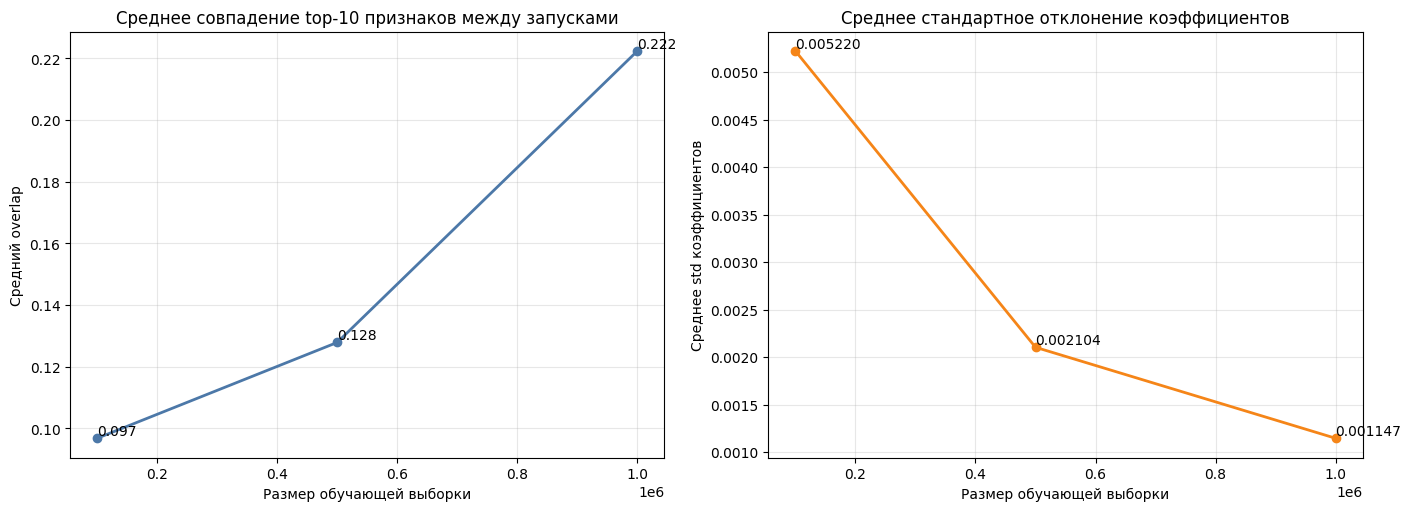

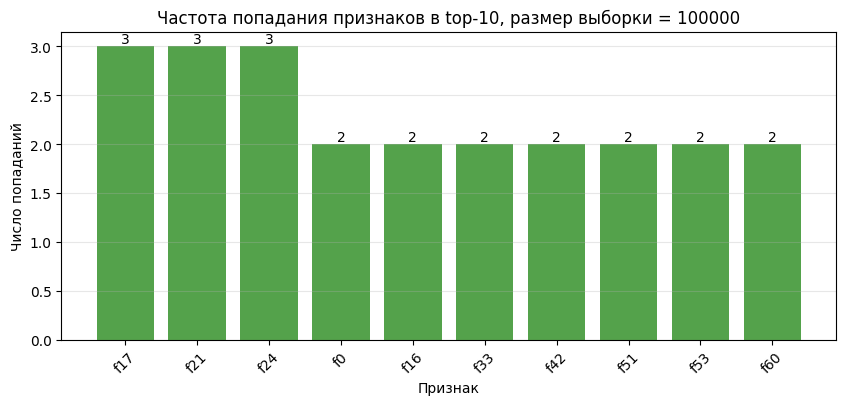

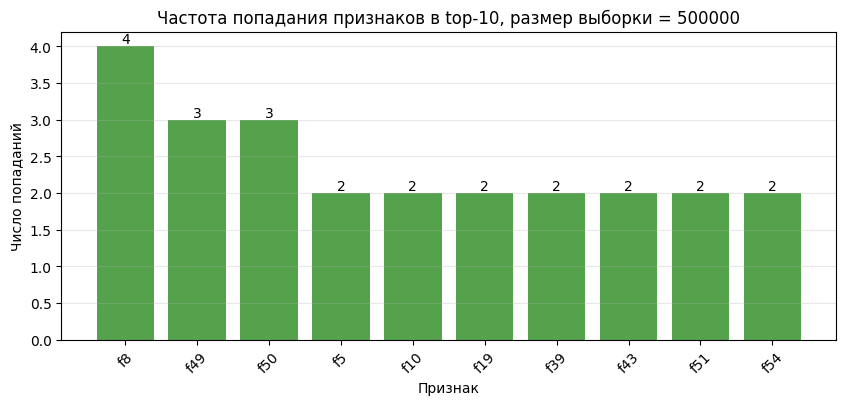

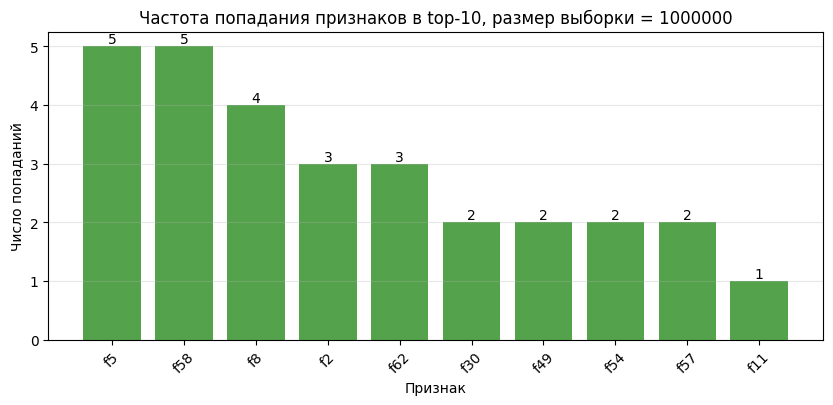

In [35]:
def plot_stability_summary(stability_summary: dict, top_frequency_tables: dict) -> None:
    sample_sizes = list(stability_summary.keys())
    top_overlap = [stability_summary[size]['mean_pairwise_top_overlap'] for size in sample_sizes]
    coef_std = [stability_summary[size]['mean_coef_std'] for size in sample_sizes]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

    axes[0].plot(sample_sizes, top_overlap, marker='o', linewidth=2, color='#4c78a8')
    axes[0].set_title('Среднее совпадение top-10 признаков между запусками')
    axes[0].set_xlabel('Размер обучающей выборки')
    axes[0].set_ylabel('Средний overlap')
    axes[0].grid(alpha=0.3)

    for x_value, y_value in zip(sample_sizes, top_overlap):
        axes[0].text(x_value, y_value, f'{y_value:.3f}', ha='left', va='bottom')

    axes[1].plot(sample_sizes, coef_std, marker='o', linewidth=2, color='#f58518')
    axes[1].set_title('Среднее стандартное отклонение коэффициентов')
    axes[1].set_xlabel('Размер обучающей выборки')
    axes[1].set_ylabel('Среднее std коэффициентов')
    axes[1].grid(alpha=0.3)

    for x_value, y_value in zip(sample_sizes, coef_std):
        axes[1].text(x_value, y_value, f'{y_value:.6f}', ha='left', va='bottom')

    plt.show()

    for sample_size in sample_sizes:
        top_rows = top_frequency_tables[sample_size][:10]
        labels = [f"f{row['feature_index']}" for row in top_rows]
        values = [row['top_frequency'] for row in top_rows]

        fig, ax = plt.subplots(figsize=(10, 4))
        ax.bar(labels, values, color='#54a24b')
        ax.set_title(f'Частота попадания признаков в top-10, размер выборки = {sample_size}')
        ax.set_xlabel('Признак')
        ax.set_ylabel('Число попаданий')
        ax.grid(axis='y', alpha=0.3)
        ax.tick_params(axis='x', rotation=45)
        for label, value in zip(labels, values):
            ax.text(label, value, str(value), ha='center', va='bottom')
        plt.show()


plot_stability_summary(stability_summary, top_frequency_tables)


### 5.1. Эксперимент по объему данных на одном ядре

Следующие ячейки измеряют время обучения модели на разных объемах обучающей выборки в последовательном режиме (при использовании одного вычислителя)


In [36]:
TRAIN_SIZE_STEPS = [
    50_000,
    100_000,
    250_000,
    500_000,
    750_000,
    1_000_000,
    1_500_000,
    2_000_000
]

TRAIN_SIZE_STEPS


[50000, 100000, 250000, 500000, 750000, 1000000, 1500000, 2000000]

In [37]:
volume_experiment_results = []

for n_rows in TRAIN_SIZE_STEPS:
    X_subset, y_subset = subset_by_size(X_train_std, y_train, n_rows)
    current_model = build_logistic_regression(MODEL_CONFIG)
    current_model, fit_time = fit_with_thread_limit(current_model, X_subset, y_subset, 1)
    subset_metrics = evaluate_classifier(current_model, X_test_std, y_test)

    volume_experiment_results.append({
        'n_rows': n_rows,
        'n_threads': 1,
        'fit_time_sec': fit_time,
        'test_accuracy': subset_metrics['accuracy'],
        'test_roc_auc': subset_metrics['roc_auc'],
        'test_log_loss': subset_metrics['log_loss']
    })

volume_rows = [
    {
        'n_rows': row['n_rows'],
        'fit_time_sec': f"{row['fit_time_sec']:.6f}",
        'test_accuracy': f"{row['test_accuracy']:.6f}",
        'test_roc_auc': f"{row['test_roc_auc']:.6f}",
        'test_log_loss': f"{row['test_log_loss']:.6f}"
    }
    for row in volume_experiment_results
]

print(format_text_table(volume_rows, [('n_rows', 'Размер train'), ('fit_time_sec', 'Время, сек'), ('test_accuracy', 'Test acc'), ('test_roc_auc', 'Test ROC-AUC'), ('test_log_loss', 'Test LogLoss')], 'Эксперимент по объему данных на одном ядре'))


Эксперимент по объему данных на одном ядре

Размер train | Время, сек | Test acc | Test ROC-AUC | Test LogLoss
-------------+------------+----------+--------------+-------------
50000        | 2.485523   | 0.499665 | 0.499675     | 0.697364    
100000       | 6.052006   | 0.499708 | 0.500581     | 0.693376    
250000       | 16.621435  | 0.499648 | 0.499795     | 0.693272    
500000       | 34.202461  | 0.498835 | 0.499225     | 0.693217    
750000       | 51.766745  | 0.500245 | 0.500031     | 0.693197    
1000000      | 72.776764  | 0.500478 | 0.499920     | 0.693184    
1500000      | 111.975893 | 0.499688 | 0.499342     | 0.693175    
2000000      | 146.128492 | 0.499283 | 0.499559     | 0.693164    


## 6. Построение модели: время построения в зависимости от числа вычислителей

В этом блоке сравниваем, как разное количество вычислителей влияет на время обучения модели

In [38]:
PARALLEL_THREAD_STEPS = [2, 4]
PARALLEL_TRAIN_SIZE_STEPS = TRAIN_SIZE_STEPS.copy()

PARALLEL_THREAD_STEPS, PARALLEL_TRAIN_SIZE_STEPS


([2, 4], [50000, 100000, 250000, 500000, 750000, 1000000, 1500000, 2000000])

In [55]:
parallel_volume_experiment_results = []

for n_threads in PARALLEL_THREAD_STEPS:
    for n_rows in PARALLEL_TRAIN_SIZE_STEPS:
        X_subset, y_subset = subset_by_size(X_train_std, y_train, n_rows)
        current_model = build_logistic_regression(MODEL_CONFIG)
        current_model, fit_time = fit_with_thread_limit(current_model, X_subset, y_subset, n_threads)
        subset_metrics = evaluate_classifier(current_model, X_test_std, y_test)

        parallel_volume_experiment_results.append({
            'n_rows': n_rows,
            'n_threads': n_threads,
            'fit_time_sec': fit_time,
            'test_accuracy': subset_metrics['accuracy'],
            'test_roc_auc': subset_metrics['roc_auc'],
            'test_log_loss': subset_metrics['log_loss']
        })

parallel_rows = [
    {
        'n_threads': row['n_threads'],
        'n_rows': row['n_rows'],
        'fit_time_sec': f"{row['fit_time_sec']:.6f}",
        'test_accuracy': f"{row['test_accuracy']:.6f}",
        'test_roc_auc': f"{row['test_roc_auc']:.6f}",
        'test_log_loss': f"{row['test_log_loss']:.6f}"
    }
    for row in parallel_volume_experiment_results
]

print(format_text_table(parallel_rows, [('n_threads', 'Ядра'), ('n_rows', 'Размер train'), ('fit_time_sec', 'Время, сек'), ('test_accuracy', 'Test acc'), ('test_roc_auc', 'Test ROC-AUC'), ('test_log_loss', 'Test LogLoss')], 'Эксперимент по объему данных при параллельном выполнении'))


Эксперимент по объему данных при параллельном выполнении

Ядра | Размер train | Время, сек | Test acc | Test ROC-AUC | Test LogLoss
-----+--------------+------------+----------+--------------+-------------
2    | 50000        | 2.438727   | 0.499665 | 0.499675     | 0.697364    
2    | 100000       | 6.024638   | 0.499708 | 0.500581     | 0.693376    
2    | 250000       | 16.504104  | 0.499648 | 0.499795     | 0.693272    
2    | 500000       | 34.239540  | 0.498835 | 0.499225     | 0.693217    
2    | 750000       | 51.918034  | 0.500245 | 0.500031     | 0.693197    
2    | 1000000      | 72.671259  | 0.500478 | 0.499920     | 0.693184    
2    | 1500000      | 111.646522 | 0.499688 | 0.499342     | 0.693175    
2    | 2000000      | 145.818172 | 0.499283 | 0.499559     | 0.693164    
4    | 50000        | 2.481841   | 0.499665 | 0.499675     | 0.697364    
4    | 100000       | 6.032930   | 0.499708 | 0.500581     | 0.693376    
4    | 250000       | 16.572518  | 0.499648 | 0.499795

### 7.5. Графики и визуализация оценок модели

Далее визуализируем данные, полученыне выше

In [56]:
def plot_timing_summary(timing_summary: dict) -> None:
    labels = [
        'Обучение на train',
        'Предсказание на train',
        'Предсказание на test'
    ]
    values = [
        timing_summary['train_fit_time_sec'],
        timing_summary['train_predict_time_sec'],
        timing_summary['test_predict_time_sec']
    ]

    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.bar(labels, values, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    ax.set_title('Время базового запуска модели')
    ax.set_ylabel('Время, сек')
    ax.grid(axis='y', alpha=0.3)

    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{value:.4f}', ha='center', va='bottom')

    plt.xticks(rotation=10)
    plt.show()


def plot_train_test_metrics(train_metrics: dict, test_metrics: dict) -> None:
    metric_order = ['accuracy', 'roc_auc', 'log_loss', 'pr_auc']
    metric_names = [metric for metric in metric_order if metric in train_metrics and metric in test_metrics]
    x = np.arange(len(metric_names))
    width = 0.35

    train_values = [train_metrics[metric] for metric in metric_names]
    test_values = [test_metrics[metric] for metric in metric_names]

    fig, ax = plt.subplots(figsize=(10, 4))
    bars1 = ax.bar(x - width / 2, train_values, width, label='Train', color='#4c78a8')
    bars2 = ax.bar(x + width / 2, test_values, width, label='Test', color='#f58518')
    ax.set_title('Сравнение метрик на train и test')
    ax.set_ylabel('Значение метрики')
    ax.set_xticks(x)
    ax.set_xticklabels(metric_names)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    for bars in [bars1, bars2]:
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{bar.get_height():.4f}', ha='center', va='bottom')

    plt.show()


def plot_experiment_curves(results: list[dict], x_key: str, x_label: str, title_prefix: str) -> None:
    x_values = [row[x_key] for row in results]

    fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)
    metrics_to_plot = [
        ('fit_time_sec', 'Время обучения, сек', '#1f77b4'),
        ('test_accuracy', 'Accuracy на test', '#2ca02c'),
        ('test_roc_auc', 'ROC-AUC на test', '#d62728'),
        ('test_log_loss', 'LogLoss на test', '#9467bd')
    ]

    for ax, (metric_key, metric_label, color) in zip(axes.flat, metrics_to_plot):
        y_values = [row[metric_key] for row in results]
        ax.plot(x_values, y_values, marker='o', linewidth=2, color=color)
        ax.set_title(metric_label)
        ax.set_xlabel(x_label)
        ax.set_ylabel(metric_label)
        ax.grid(alpha=0.3)

        for x_value, y_value in zip(x_values, y_values):
            label = f'{y_value:.4f}' if isinstance(y_value, float) else str(y_value)
            ax.text(x_value, y_value, label, fontsize=9, ha='left', va='bottom')

    fig.suptitle(title_prefix, fontsize=14)
    plt.show()


def filter_results_by_threads(results: list[dict], n_threads: int) -> list[dict]:
    filtered = [row for row in results if row['n_threads'] == n_threads]
    return sorted(filtered, key=lambda row: row['n_rows'])


def plot_thread_comparison(results_1: list[dict], results_parallel: list[dict], metric_key: str, metric_label: str) -> None:
    series = {
        1: sorted(results_1, key=lambda row: row['n_rows']),
        2: filter_results_by_threads(results_parallel, 2),
        4: filter_results_by_threads(results_parallel, 4)
    }

    colors = {1: '#1f77b4', 2: '#ff7f0e', 4: '#2ca02c'}

    fig, ax = plt.subplots(figsize=(10, 5))
    for n_threads, rows in series.items():
        if not rows:
            continue
        x_values = [row['n_rows'] for row in rows]
        y_values = [row[metric_key] for row in rows]
        ax.plot(x_values, y_values, marker='o', linewidth=2, label=f'{n_threads} ядра', color=colors[n_threads])
        for x_value, y_value in zip(x_values, y_values):
            ax.text(x_value, y_value, f'{y_value:.4f}', fontsize=8, ha='left', va='bottom')

    ax.set_title(f'Сравнение {metric_label} для 1, 2 и 4 ядер')
    ax.set_xlabel('Число объектов train')
    ax.set_ylabel(metric_label)
    ax.grid(alpha=0.3)
    ax.legend()
    plt.show()


### Базовые графики для одного полного запуска модели

Сначала строим графики для одного полного запуска: отдельно показываем время обучения и время предсказания, а затем сравниваются метрики качества на `train` и `test`. Это нужно, чтобы увидеть общую вычислительную стоимость модели и проверить, нет ли слишком сильного расхождения между обучающей и тестовой выборками

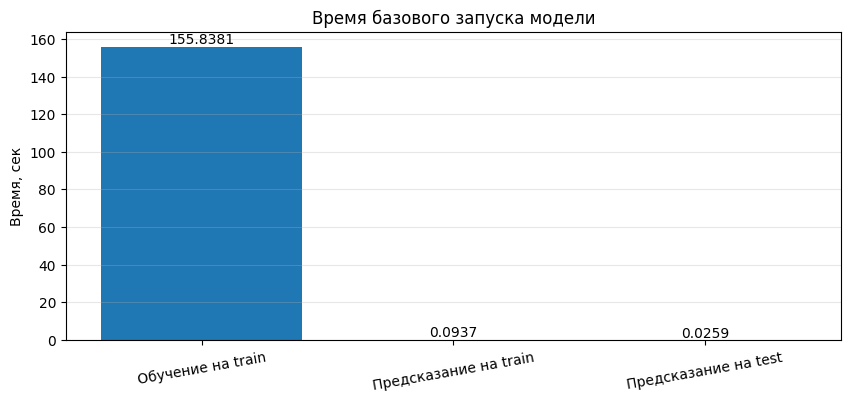

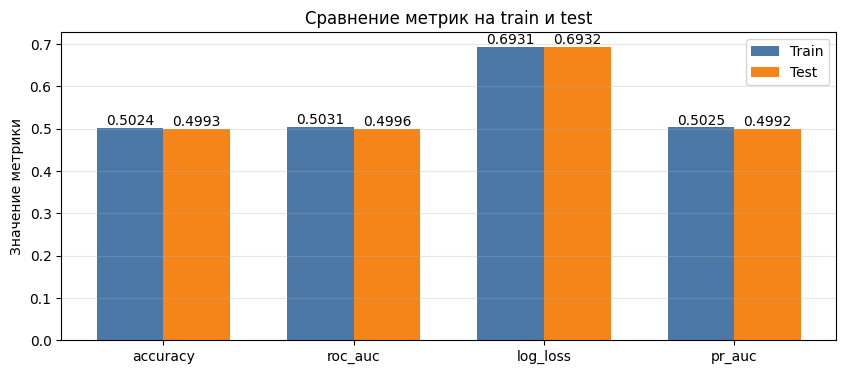

In [68]:
plot_timing_summary(timing_summary)
plot_train_test_metrics(train_metrics, test_metrics)

### Графики зависимости от объема данных на одном ядре

Эти графики показывают, как меняется время обучения и качество модели при увеличении размера обучающей выборки в последовательном режиме

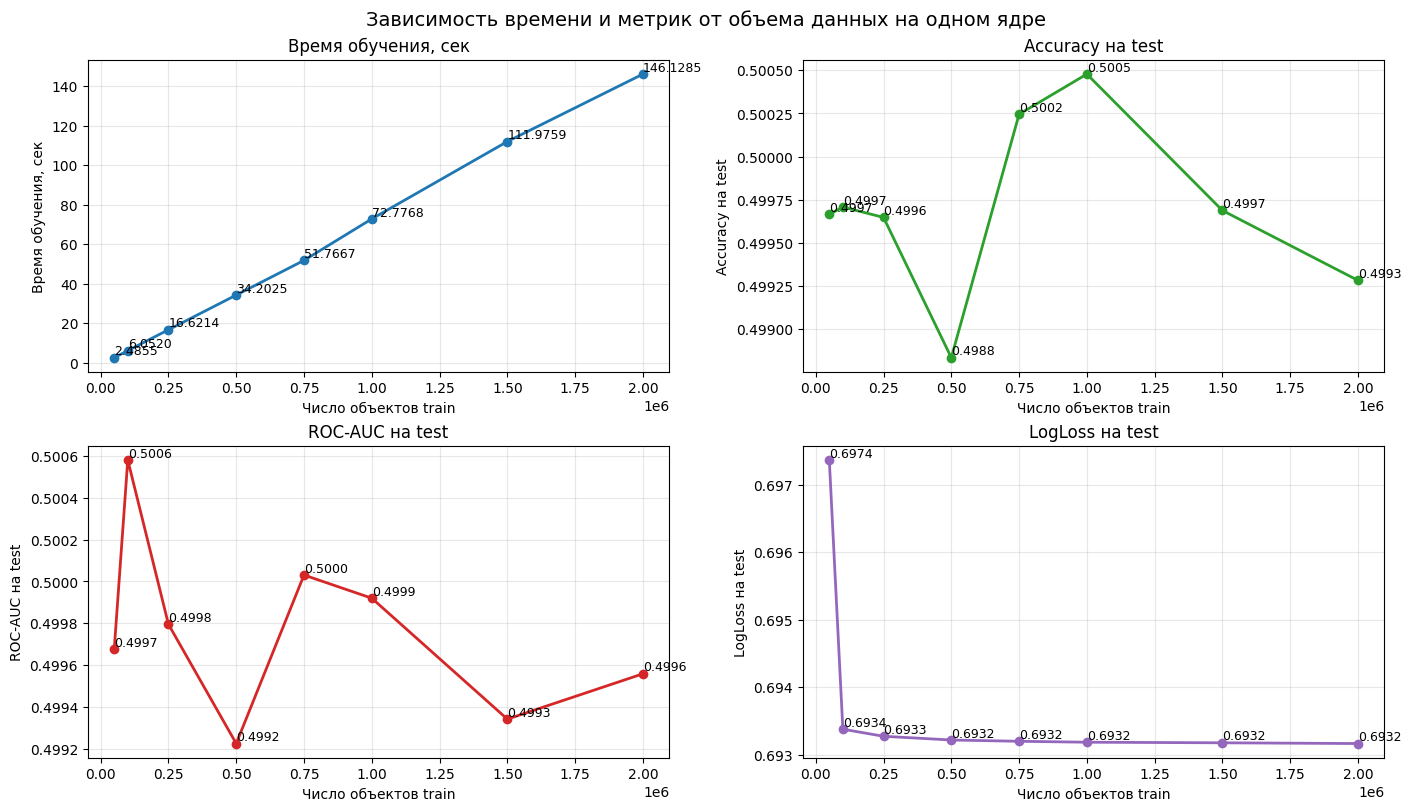

In [69]:
plot_experiment_curves(volume_experiment_results, 'n_rows', 'Число объектов train', 'Зависимость времени и метрик от объема данных на одном ядре')


### Графики зависимости от объема данных при параллельном выполнении

Здесь отображается тот же эксперимент по объему данных, но для параллельных режимов с `2` и `4` вычислителями. Это позволяет напрямую сравнить последовательное и параллельное обучение на одинаковых подвыборках

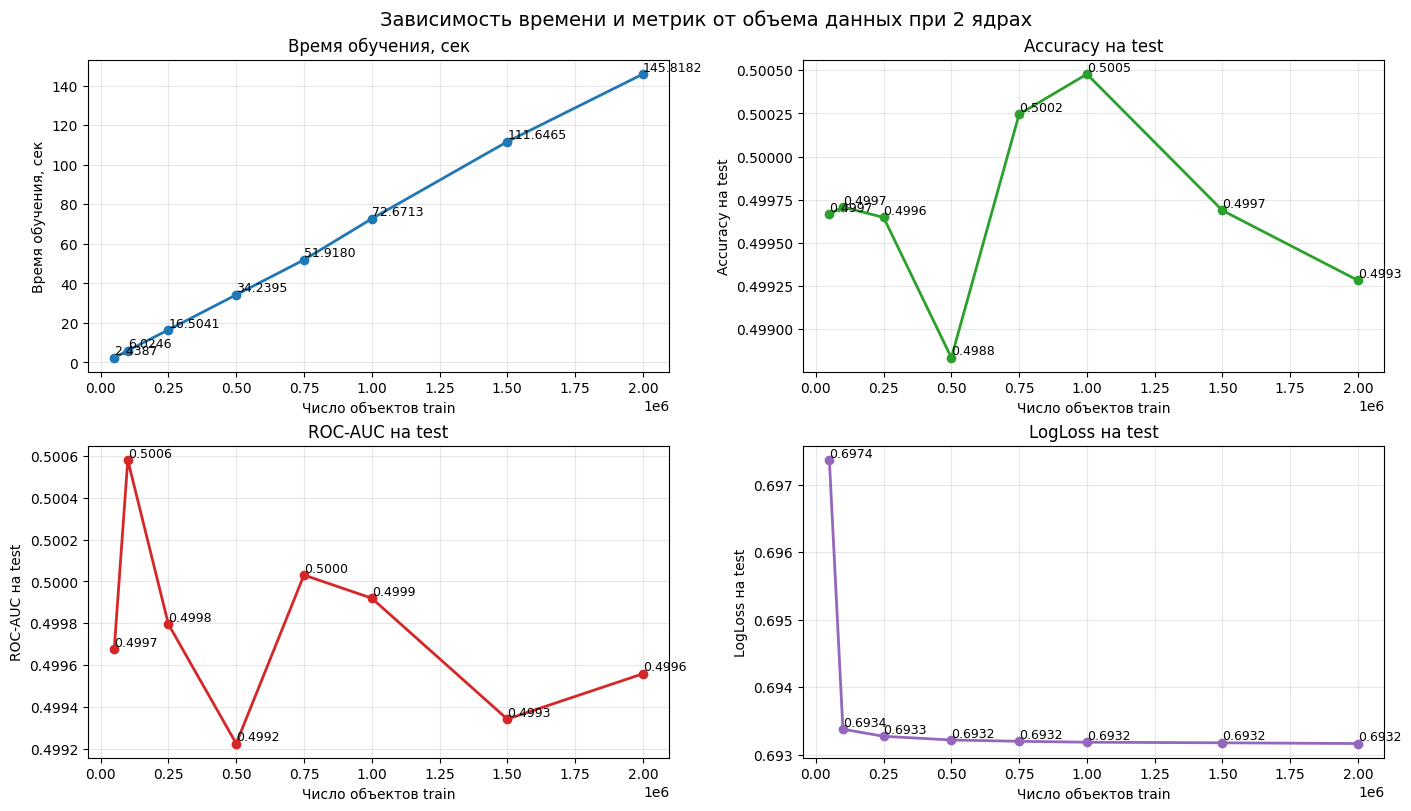

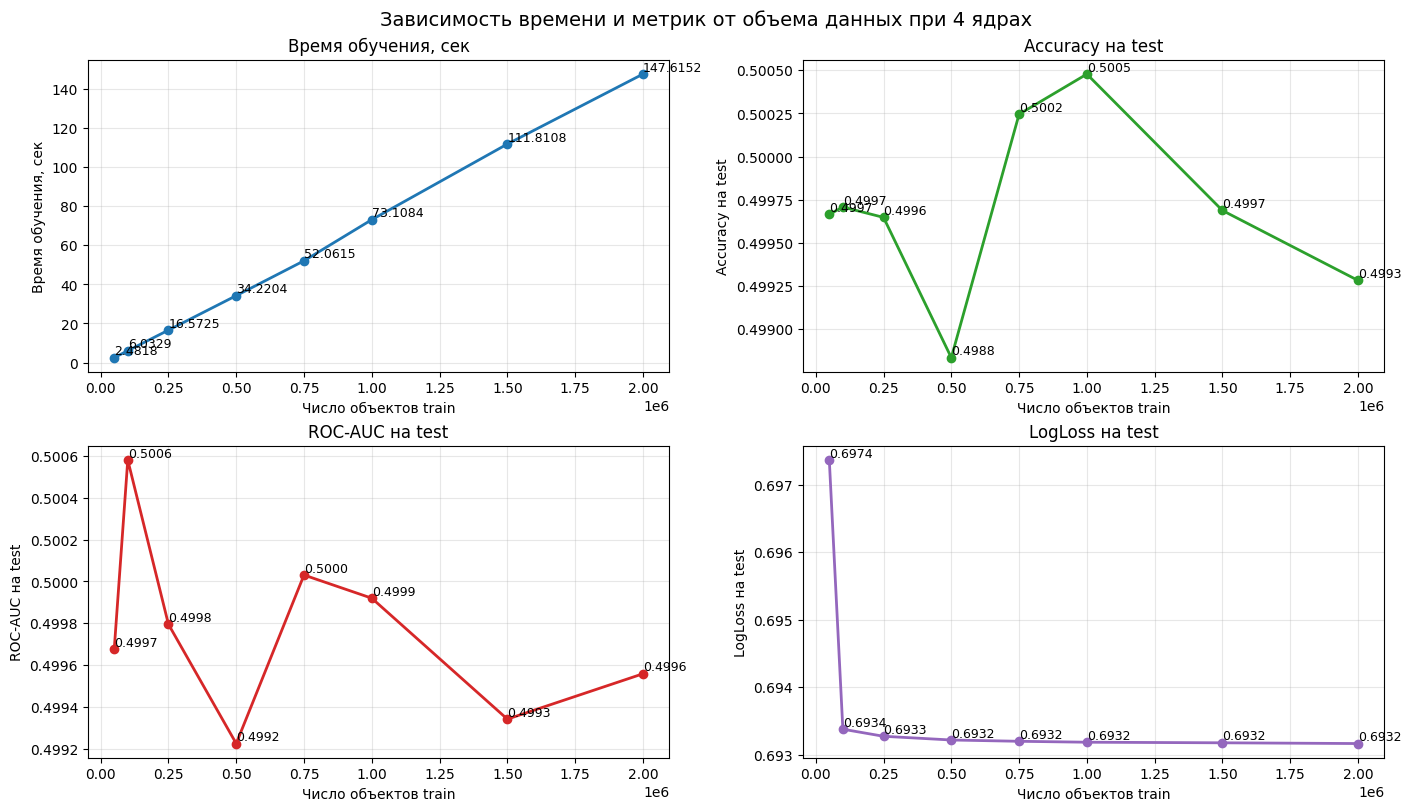

In [70]:
plot_experiment_curves(filter_results_by_threads(parallel_volume_experiment_results, 2), 'n_rows', 'Число объектов train', 'Зависимость времени и метрик от объема данных при 2 ядрах')
plot_experiment_curves(filter_results_by_threads(parallel_volume_experiment_results, 4), 'n_rows', 'Число объектов train', 'Зависимость времени и метрик от объема данных при 4 ядрах')


### Сравнение 1, 2 и 4 ядер на одних и тех же объемах данных

Следующие графики напрямую сравнивают результаты последовательного режима и параллельных режимов при `2` и `4` ядрах

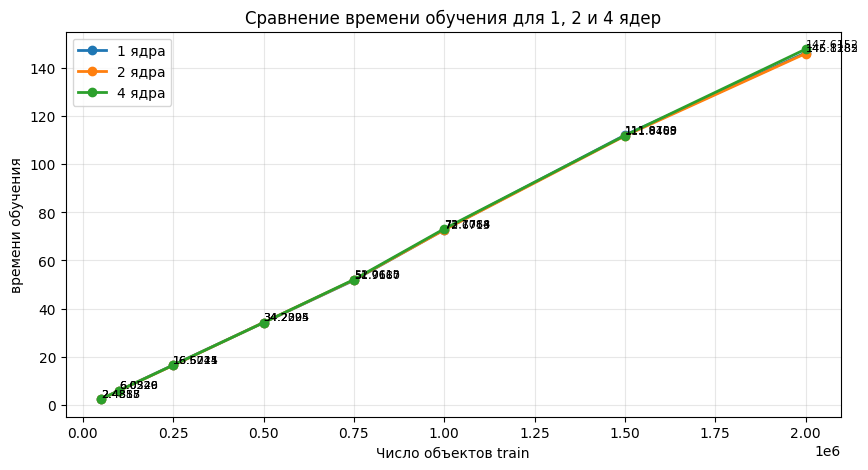

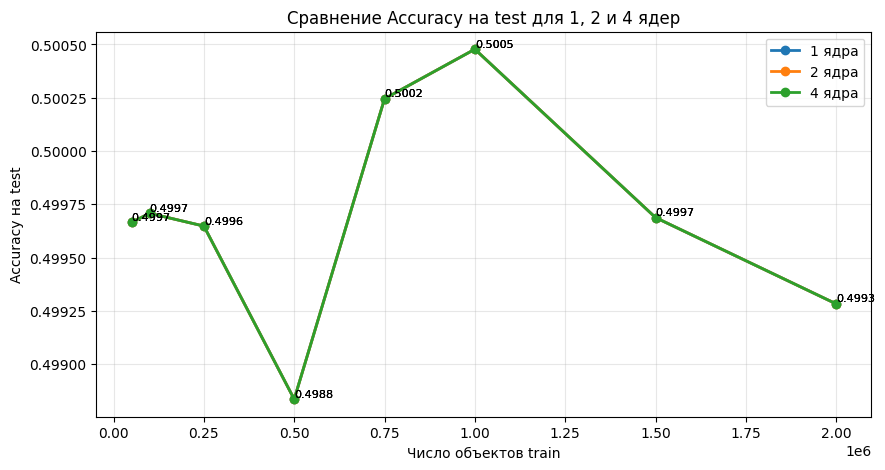

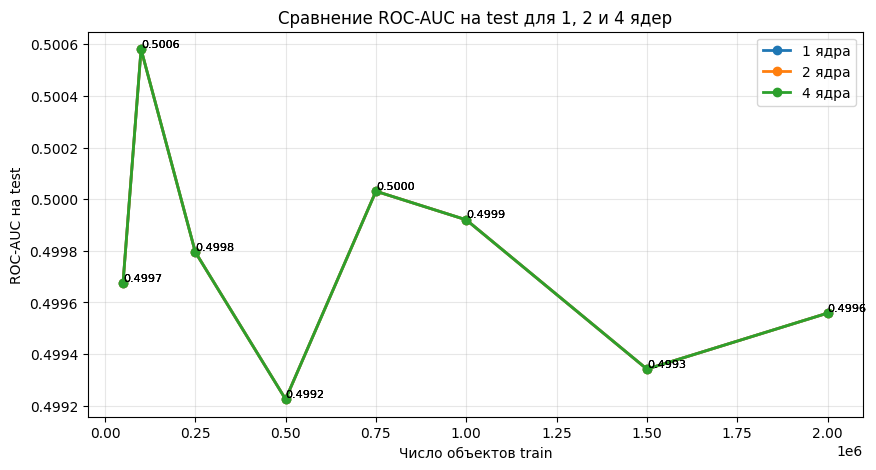

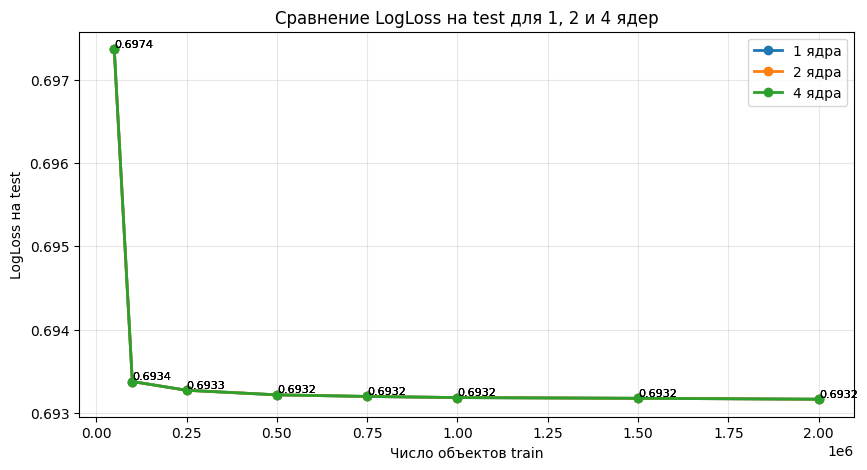

In [71]:
plot_thread_comparison(volume_experiment_results, parallel_volume_experiment_results, 'fit_time_sec', 'времени обучения')
plot_thread_comparison(volume_experiment_results, parallel_volume_experiment_results, 'test_accuracy', 'Accuracy на test')
plot_thread_comparison(volume_experiment_results, parallel_volume_experiment_results, 'test_roc_auc', 'ROC-AUC на test')
plot_thread_comparison(volume_experiment_results, parallel_volume_experiment_results, 'test_log_loss', 'LogLoss на test')


### Графическое сравнение raw и phi-features

На этих графиках один и тот же алгоритм сравнивается на `raw` и `phi`-признаках. Сопоставляются как метрики качества, так и время обучения, чтобы оценить не только точность, но и практическую вычислительную стоимость каждого подхода

In [72]:
def plot_raw_vs_phi_results(raw_vs_phi_results: dict) -> None:
    modes = ['raw', 'phi']
    fit_times = [raw_vs_phi_results[mode]['train_fit_time_sec'] for mode in modes]
    test_accuracies = [raw_vs_phi_results[mode]['test_metrics']['accuracy'] for mode in modes]
    test_roc_auc = [raw_vs_phi_results[mode]['test_metrics']['roc_auc'] for mode in modes]
    test_log_loss = [raw_vs_phi_results[mode]['test_metrics']['log_loss'] for mode in modes]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
    plots = [
        (fit_times, 'Время обучения, сек', '#1f77b4'),
        (test_accuracies, 'Accuracy на test', '#2ca02c'),
        (test_roc_auc, 'ROC-AUC на test', '#d62728'),
        (test_log_loss, 'LogLoss на test', '#9467bd')
    ]

    for ax, (values, title, color) in zip(axes.flat, plots):
        bars = ax.bar(modes, values, color=color)
        ax.set_title(title)
        ax.grid(axis='y', alpha=0.3)
        for bar, value in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{value:.4f}', ha='center', va='bottom')

    plt.show()


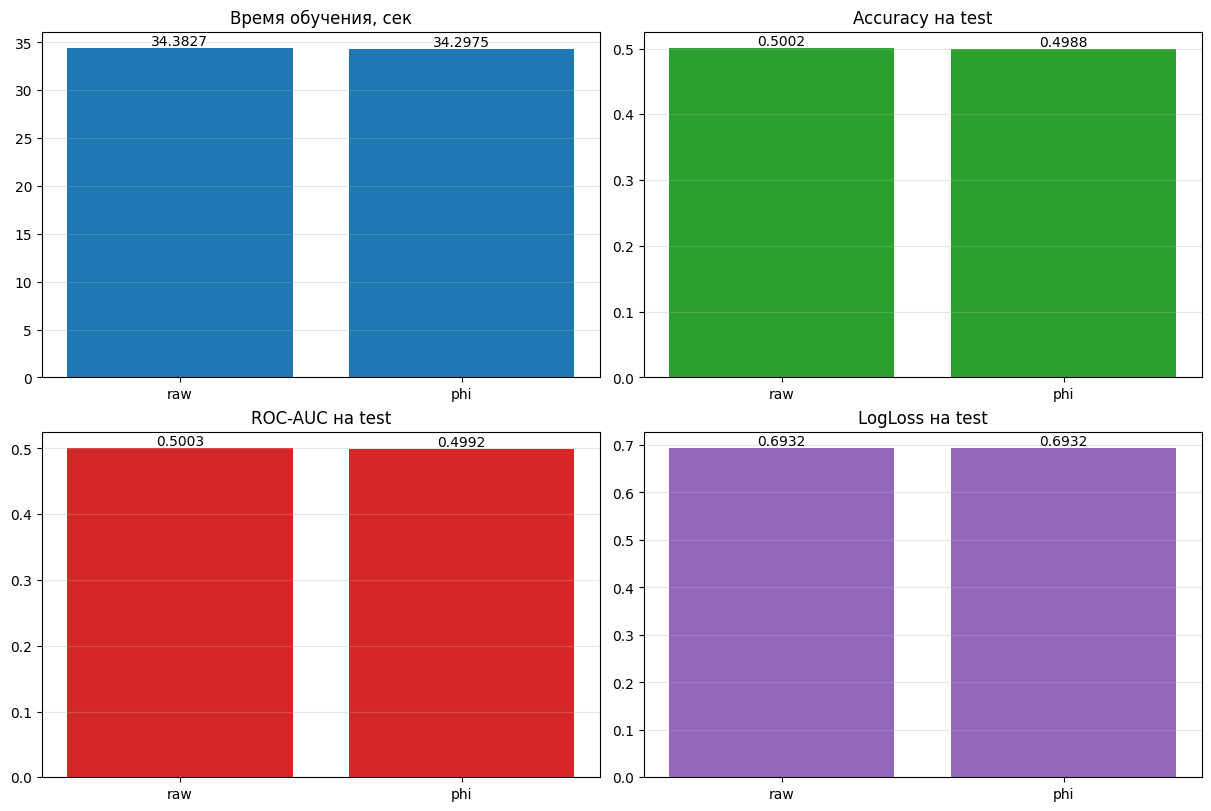

In [73]:
plot_raw_vs_phi_results(raw_vs_phi_results)


## 8. Выводы

В работе мы исследовали датасет `XOR Arbiter PUFs` с использованием логистической регрессии с `L1`-регуляризацией. Результаты показали, что выбранная линейная модель не выявляет выраженной зависимости между признаками и откликом функции: значения `Accuracy`, `ROC-AUC` и `PR-AUC` на тестовой выборке остаются близкими к `0.5`, а `LogLoss` близок к `0.693`.

Анализ коэффициентов показал отсутствие разреженности и отсутствие явно доминирующих признаков: все веса ненулевые, но малы и близки друг к другу по масштабу. Сравнение `raw` и `phi-features` не дало заметного различия в качестве модели, а анализ устойчивости отбора признаков показал лишь частичную стабильность на больших выборках.

Таким образом, для исследуемого XOR Arbiter PUF логистическая регрессия с `L1`-регуляризацией не обнаруживает сильной предсказательной и интерпретируемой структуры. Это означает, что выбранный тип функции плохо описывается данным линейным методом и остается сложным объектом для простой линейной моделирующей атаки.
